<img src="../Decorative-Elements/Section-05/ADL-S05-Image-03-d.png">

<p style="display: flex; justify-content: space-between;">
  <a href="../05-Applications/03-Resonance-Effects-in-Planet.ipynb" target="_blank">Previous</a>
  <a href="../05-Applications/05-Black-Hole-Formation.ipynb" target="_blank">Next</a>
</p>

In [1]:
# Study of Saturn's Rings

# Saturn's rings are a system of countless small particles
# orbiting the planet in nearly circular, coplanar paths.

# The rings are primarily composed of ice-rich fragments
# ranging in size from micrometers to meters.

# Ring structure is shaped by:
# - Gravitational forces from Saturn.
# - Resonances with Saturn’s moons.
# - Collisions between ring particles.
# - Self-gravity within dense ring regions.

# Gaps and divisions (e.g., Cassini Division)
# arise due to orbital resonances with nearby moons.

# Studying Saturn’s rings helps us understand:
# - Disk dynamics and planet formation.
# - Resonance effects in gravitational systems.
# - Collisional and collective behavior in thin disks.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import rebound
import plotly.graph_objects as go

In [3]:
# Saturn Ring System Parameters

# Gravitational constant (AU, yr, Solar mass units)
G = 4 * np.pi**2

# Saturn mass in Solar mass units
M_saturn = 2.857e-4  

# Major ring boundaries (approximate, in AU)
# Converted from km → AU (1 AU ≈ 1.496e8 km)
R_inner = 70000 / 1.496e8
R_outer = 140000 / 1.496e8

print("Saturn Mass (Msun):", M_saturn)
print("Ring Inner Radius (AU):", R_inner)
print("Ring Outer Radius (AU):", R_outer)

Saturn Mass (Msun): 0.0002857
Ring Inner Radius (AU): 0.0004679144385026738
Ring Outer Radius (AU): 0.0009358288770053476


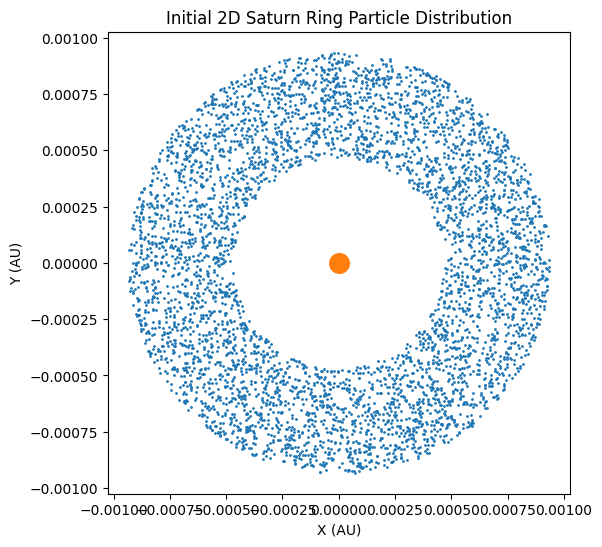

In [4]:
# 2D Saturn Ring Particle Distribution
N_particles = 5000

# Random radial distribution (uniform surface density)
r = np.sqrt(np.random.uniform(R_inner**2, R_outer**2, N_particles))

# Random angular distribution
theta = np.random.uniform(0, 2*np.pi, N_particles)

# Convert to Cartesian coordinates
x = r * np.cos(theta)
y = r * np.sin(theta)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=1)

# Saturn at center
plt.scatter(0, 0, s=200)

plt.gca().set_aspect('equal')
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.title("Initial 2D Saturn Ring Particle Distribution")
plt.show()

In [5]:
#  Local Patch of Saturn's Rings (Shearing Sheet Model)

sim = rebound.Simulation()

# Orbital angular frequency of ring patch (rad/s)
# Sets local Keplerian rotation rate
OMEGA = 0.00013143527 
sim.ri_sei.OMEGA = OMEGA

# Physical properties
surface_density = 400.      # kg/m^2 (typical dense ring region)
particle_density = 400.     # kg/m^3 (icy particles)

# Gravitational constant (SI units)
sim.G = 6.67428e-11  

# Time step scaled to orbital period
sim.dt = 1e-3 * 2.*np.pi / OMEGA

# Gravitational softening to avoid singularities
sim.softening = 0.2

# Local simulation box size (meters)
boxsize = 200.
sim.configure_box(boxsize)

# Periodic shear boundary conditions
sim.N_ghost_x = 2
sim.N_ghost_y = 2
sim.boundary = "shear"

# SEI integrator = Symplectic Epicycle Integrator
sim.integrator = "sei"

# Tree gravity for self-gravity between particles
sim.gravity = "tree"

# Tree collision detection with hard-sphere resolution
sim.collision = "tree"
sim.collision_resolve = "hardsphere"

# Velocity-dependent coefficient of restitution
# Models inelastic icy particle collisions
def cor_bridges(r, v):
    eps = 0.32 * pow(abs(v)*100., -0.234)
    if eps > 1.: eps = 1.
    if eps < 0.: eps = 0.
    return eps

sim.coefficient_of_restitution = cor_bridges

# Power-law size distribution for particles
# slope = -3 approximates collisional equilibrium
def powerlaw(slope, min_v, max_v):
    y = np.random.uniform()
    pow_max = pow(max_v, slope+1.)
    pow_min = pow(min_v, slope+1.)
    return pow((pow_max - pow_min)*y + pow_min, 1./(slope+1.))

# Add particles until target surface density reached
total_mass = 0.

while total_mass < surface_density * (boxsize**2):

    radius = powerlaw(slope=-3, min_v=1, max_v=4)  # meters
    mass = particle_density * 4./3. * np.pi * (radius**3)

    x = np.random.uniform(-boxsize/2., boxsize/2.)
    
    sim.add(
        m = mass,
        r = radius,
        x = x,
        y = np.random.uniform(-boxsize/2., boxsize/2.),
        z = np.random.normal(),
        vx = 0.,
        vy = -3./2. * x * OMEGA,  # Keplerian shear velocity
        vz = 0.
    )
    
    total_mass += mass

print("Number of particles:", sim.N)

Number of particles: 1386


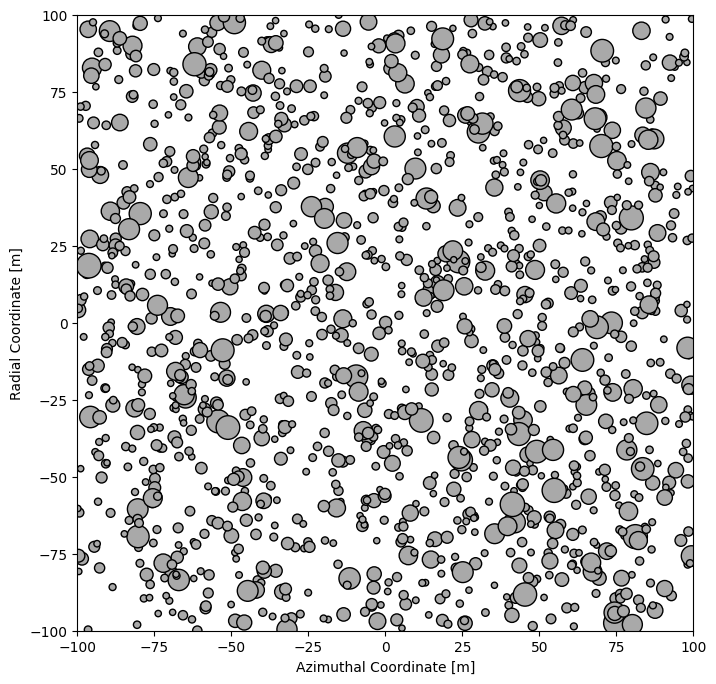

In [6]:
# Visualize Ring Patch Evolution

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plotParticles(sim):
    fig = plt.figure(figsize=(8,8))
    ax = plt.subplot(111, aspect='equal')

    ax.set_ylabel("Radial Coordinate [m]")
    ax.set_xlabel("Azimuthal Coordinate [m]")

    ax.set_ylim(-boxsize/2., boxsize/2.)
    ax.set_xlim(-boxsize/2., boxsize/2.)

    for p in sim.particles:
        circ = patches.Circle(
            (p.y, p.x),
            p.r,
            facecolor='darkgray',
            edgecolor='black'
        )
        ax.add_patch(circ)

    plt.show()

# Initial configuration
plotParticles(sim)

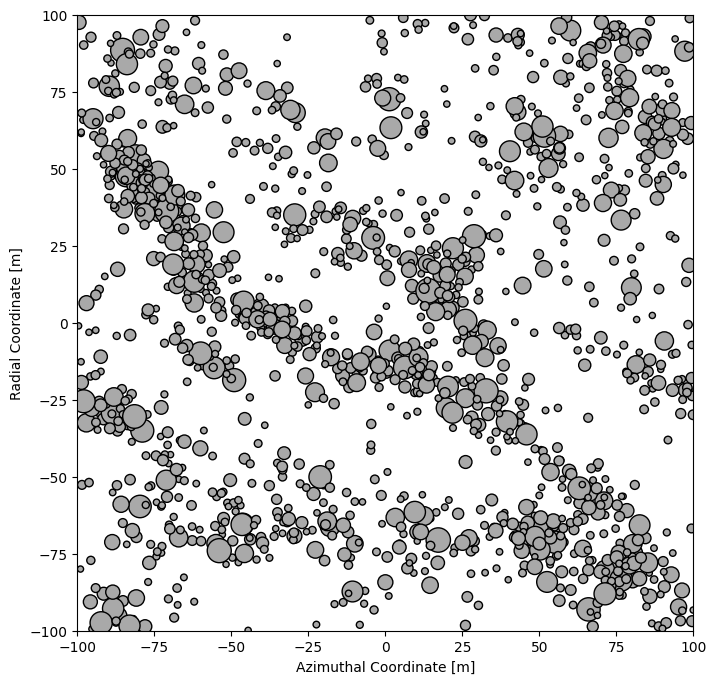

In [7]:
# Integrate for one orbital period
sim.integrate(2. * np.pi / OMEGA)

# After evolution
plotParticles(sim)

In [8]:
# Compute Toomre Q Parameter
# Extract particle data
particles = sim.particles

# Radial velocities (x-direction in shearing sheet)
vx = np.array([p.vx for p in particles])

# Surface density (already defined)
Sigma = surface_density

# Velocity dispersion (radial)
sigma_r = np.std(vx)

# Epicyclic frequency (equal to OMEGA in Keplerian disk)
kappa = OMEGA

# Toomre Q formula
# Q = (sigma_r * kappa) / (pi * G * Sigma)

Q = (sigma_r * kappa) / (np.pi * sim.G * Sigma)

print("Radial velocity dispersion (m/s):", sigma_r)
print("Toomre Q:", Q)

Radial velocity dispersion (m/s): 0.001467779474263181
Toomre Q: 2.3001621117651143


In [9]:
# Toomre Q Stability Interpretation
# Toomre Q = Stability criterion for thin rotating disks.

# Q < 1
# → Gravitationally unstable.
# → Disk fragments or forms clumps.
# → Strong wake formation possible.

# Q ≈ 1
# → Marginally stable.
# → Self-gravity wakes can develop.
# → This regime is observed in Saturn's rings.

# Q > 1
# → Gravitationally stable.
# → Pressure (velocity dispersion) dominates gravity.
# → No large-scale clumping.

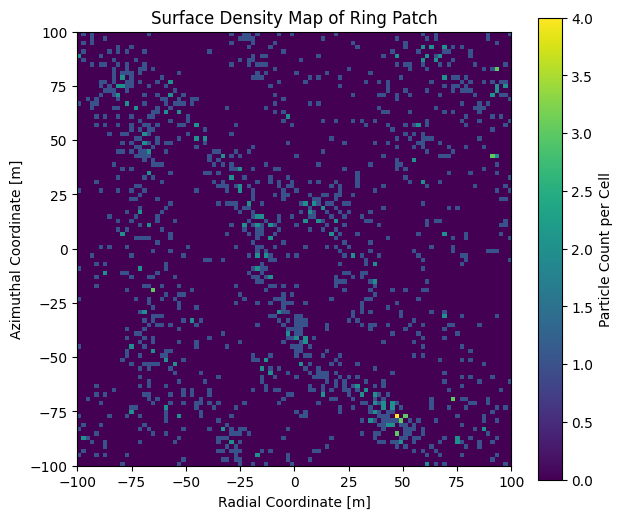

In [10]:
# 2D Surface Density Map
# Extract particle positions
x = np.array([p.x for p in sim.particles])
y = np.array([p.y for p in sim.particles])

# Grid resolution
grid_size = 100

# Create 2D histogram (surface density proxy)
density, xedges, yedges = np.histogram2d(
    x, y,
    bins=grid_size,
    range=[[-boxsize/2., boxsize/2.],
           [-boxsize/2., boxsize/2.]]
)

# Plot density map
plt.figure(figsize=(7,6))
plt.imshow(
    density.T,
    origin='lower',
    extent=[-boxsize/2., boxsize/2.,
            -boxsize/2., boxsize/2.]
)

plt.xlabel("Radial Coordinate [m]")
plt.ylabel("Azimuthal Coordinate [m]")
plt.title("Surface Density Map of Ring Patch")
plt.colorbar(label="Particle Count per Cell")
plt.show()

In [11]:
# Ring Parameters

R_inner = 70000e3
R_outer = 140000e3
N = 20000

# Structured radial bands
r_base = np.random.uniform(R_inner, R_outer, N)

# Add clear banding pattern
band_pattern = 4000e3 * np.sin((r_base - R_inner) / 5000e3)
r = r_base + band_pattern

theta = np.random.uniform(0, 2*np.pi, N)

# Add slight vertical thickness
z = np.random.normal(0, 800e3, N)

# Convert to Cartesian
x = r * np.cos(theta)
y = r * np.sin(theta)

# Tilt (Disorientation)

tilt_angle = np.radians(20)

y_tilt = y * np.cos(tilt_angle) - z * np.sin(tilt_angle)
z_tilt = y * np.sin(tilt_angle) + z * np.cos(tilt_angle)

# Saturn Sphere
R_saturn = 58232e3

phi = np.linspace(0, np.pi, 50)
theta_s = np.linspace(0, 2*np.pi, 50)
phi, theta_s = np.meshgrid(phi, theta_s)

xs = R_saturn * np.sin(phi) * np.cos(theta_s)
ys = R_saturn * np.sin(phi) * np.sin(theta_s)
zs = R_saturn * np.cos(phi)

# Apply same tilt to Saturn
ys_tilt = ys * np.cos(tilt_angle) - zs * np.sin(tilt_angle)
zs_tilt = ys * np.sin(tilt_angle) + zs * np.cos(tilt_angle)

# Plot
fig = go.Figure()

# Rings
fig.add_trace(go.Scatter3d(
    x=x,
    y=y_tilt,
    z=z_tilt,
    mode='markers',
    marker=dict(size=2),
    name="Rings"
))

# Saturn
fig.add_trace(go.Surface(
    x=xs,
    y=ys_tilt,
    z=zs_tilt,
    showscale=False,
    opacity=0.9,
    name="Saturn"
))

fig.update_layout(
    title="Tilted 3D Saturn Rings with Band Structure",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode='data',
        camera=dict(
            eye=dict(x=1.4, y=1.4, z=0.8)  # Zoomed closer
        )
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

# Output is not visible in github webpage, refer to Folder/Output-Plotly

In [12]:
# Conclusion — Applications of Saturn Ring Study

# Saturn's rings act as a natural laboratory for disk physics.

# 1. Disk Stability Theory
# - Validates Toomre Q criterion.
# - Applies to protoplanetary, galactic, and accretion disks.

# 2. Self-Gravity Wakes
# - Confirms N-body predictions of gravitational instability.
# - Explains elongated density structures observed in rings.

# 3. Resonance and Gap Formation
# - Moon resonances sculpt ring gaps.
# - Similar mechanism forms asteroid belt gaps.

# 4. Collisional Granular Dynamics
# - Rings behave like a dissipative particle fluid.
# - Important for understanding disk viscosity and energy loss.

# 5. Planet Formation Insight
# - Rings resemble early-stage protoplanetary disks.
# - Help study balance between accretion and fragmentation.

# Overall:
# Saturn's rings connect granular physics, orbital resonance,
# and large-scale astrophysical disk evolution.

<p style="display: flex; justify-content: space-between;">
  <a href="../05-Applications/03-Resonance-Effects-in-Planet.ipynb" target="_blank">Previous</a>
  <a href="../05-Applications/05-Black-Hole-Formation.ipynb" target="_blank">Next</a>
</p>
<img src="../Decorative-Elements/Section-Footer-Animated/Section-05-04.gif">